# Notebook 15 — Maps Visualisation (Improved)

## How This Connects to Module C

In the **original plan**, Module C used socioeconomic data (NSSO income, Agri Census, FPO, PMFBY)
to cluster districts by farmer participation viability and compute a **PVI score**.

In your **revised Module C**, you replaced socioeconomic data with **environmental features**:
- `fire_count` — average annual fire detections (proxy for burning pressure)
- `residue` — recoverable residue in tonnes (proxy for bioenergy feedstock)
- `avg_temp` — mean temperature during burning season (weather factor)
- `rainfall` — total seasonal rainfall (suppresses burning when high)

This change means:
- **NB13** now clusters districts into **environmental intervention zones** (High Stress/High Opportunity, Moderate Zone, Low Priority) rather than farmer viability clusters.
- **NB14** now computes a **Burning Severity Index (BSI)** using PCA-derived weights from these environmental features, rather than a Participation Viability Index (PVI).

**What this notebook does with those outputs:**
1. **BSI Map** — shows burning severity across all 47 districts (replaces the BRS map from Module A, using PCA-weighted environmental factors rather than a simple frequency + FRP + trend formula)
2. **Cluster/Zone Map** — shows the three environmental intervention zones from K-Means (replaces the socio-based PVI cluster map)
3. **Top-5 Burning Districts** — highlights the five worst districts by BSI score

**Input:** `Data/Processed/Punjab_Haryana_districts.gpkg`, `Data/Processed/bsi_scores.csv`, `Data/Processed/district_clusters.csv`  
**Output:** `Outputs/Maps/15_bsi_map.png`, `Outputs/Maps/15_cluster_map.png`, `Outputs/Maps/15_top5_burning.png`

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('../Outputs/Maps', exist_ok=True)

In [2]:
# ── Load all inputs ───────────────────────────────────────────────────────
# districts : 43–47 polygon GeoDataFrame from NB01
# bsi       : BSI score (0–100) per district from NB14 (PCA-derived environmental index)
# clusters  : K-Means zone label per district from NB13 (environmental clustering)
districts = gpd.read_file('../Data/Processed/Punjab_Haryana_districts.gpkg')
bsi       = pd.read_csv('../Data/Processed/bsi_scores.csv')
clusters  = pd.read_csv('../Data/Processed/district_clusters.csv')

# ── Standardise district name casing across all datasets ──────────────────
# The GeoPackage uses GADM NAME_2 column. Promote it to 'district' to match
# the column name used throughout NB11–NB14.
districts['district'] = districts['NAME_2'].str.strip().str.title()
bsi['district']       = bsi['district'].str.strip().str.title()
clusters['district']  = clusters['district'].str.strip().str.title()

print(f"Districts in shapefile : {len(districts)}")
print(f"Districts in BSI       : {len(bsi)}")
print(f"Districts in clusters  : {len(clusters)}")

Districts in shapefile : 43
Districts in BSI       : 47
Districts in clusters  : 47


In [3]:
# ── Merge all data into one GeoDataFrame ──────────────────────────────────
# Using left join on 'district' so all polygons are retained even if a
# district has no BSI or zone (e.g. Chandigarh UT, union territories).
gdf = (
    districts
    .merge(bsi,                              on='district', how='left')
    .merge(clusters[['district', 'zone']],   on='district', how='left')
)

missing_bsi  = gdf['BSI'].isna().sum()
missing_zone = gdf['zone'].isna().sum()
print(f"Districts missing BSI : {missing_bsi}")
print(f"Districts missing zone: {missing_zone}")

# Fill any gaps so the maps render cleanly
gdf['BSI']  = gdf['BSI'].fillna(0)
gdf['zone'] = gdf['zone'].fillna('Unknown')

print("\nSample merged data:")
print(gdf[['district', 'BSI', 'zone']].head(8).to_string(index=False))

Districts missing BSI : 0
Districts missing zone: 0

Sample merged data:
 district  BSI                           zone
   Ambala 38.6 High Stress / High Opportunity
  Bhiwani 61.5                  Moderate Zone
Faridabad 55.9                  Moderate Zone
Fatehabad 80.8              Low Priority Zone
 Gurugram 57.2                  Moderate Zone
    Hisar 77.0              Low Priority Zone
  Jhajjar 61.5                  Moderate Zone
     Jind 71.1              Low Priority Zone


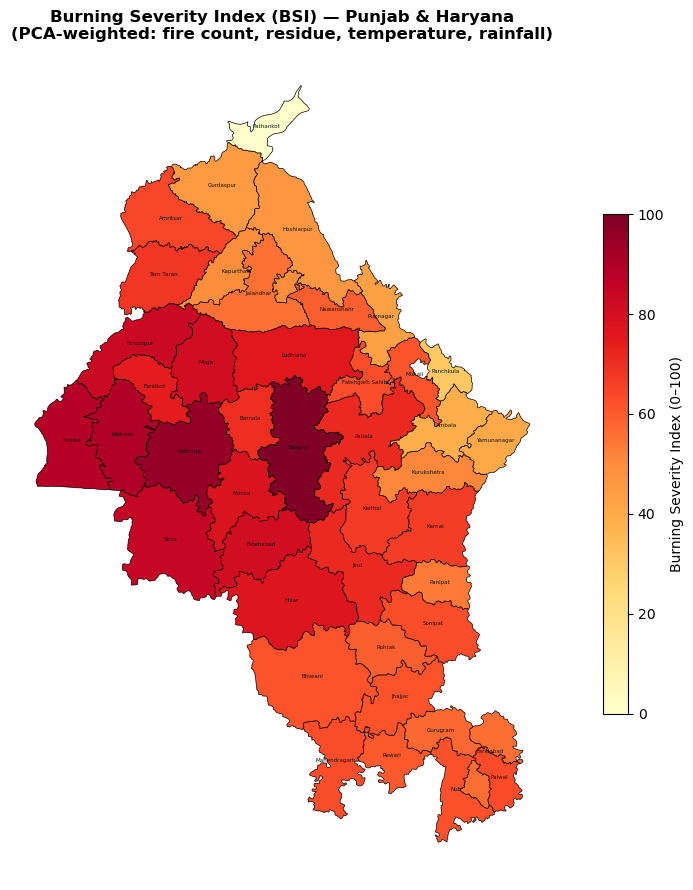

✅ Saved: Outputs/Maps/15_bsi_map.png


In [4]:
# ── Map 1: Burning Severity Index (BSI) choropleth ────────────────────────
#
# WHY BSI AND NOT JUST BRS?
# The BRS (NB06) used three manually-weighted fire metrics:
#   fire frequency 40% + fire intensity 30% + trend slope 30%
# BSI (NB14) uses PCA on four environmental features to derive
# data-driven weights, including temperature and rainfall suppression.
# BSI is therefore a richer, multi-factor severity signal that captures
# why districts burn, not just how much.
#
# Colour scale: YlOrRd — light yellow (low BSI) → deep red (high BSI).
# Districts with BSI ≥ ~84 (Sangrur, Bathinda, Muktsar, Fazilka, Sirsa)
# will appear darkest and represent the most urgent intervention targets.

fig, ax = plt.subplots(figsize=(10, 9))

gdf.plot(
    column      = 'BSI',
    cmap        = 'YlOrRd',
    linewidth   = 0.5,
    edgecolor   = 'black',
    legend      = True,
    legend_kwds = {
        'label'  : 'Burning Severity Index (0–100)',
        'shrink' : 0.6,
    },
    ax          = ax,
)

for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['district'], xy=(c.x, c.y), fontsize=4, ha='center', color='#111111')

ax.set_title(
    'Burning Severity Index (BSI) — Punjab & Haryana\n'
    '(PCA-weighted: fire count, residue, temperature, rainfall)',
    fontsize=12, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('../Outputs/Maps/15_bsi_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: Outputs/Maps/15_bsi_map.png")

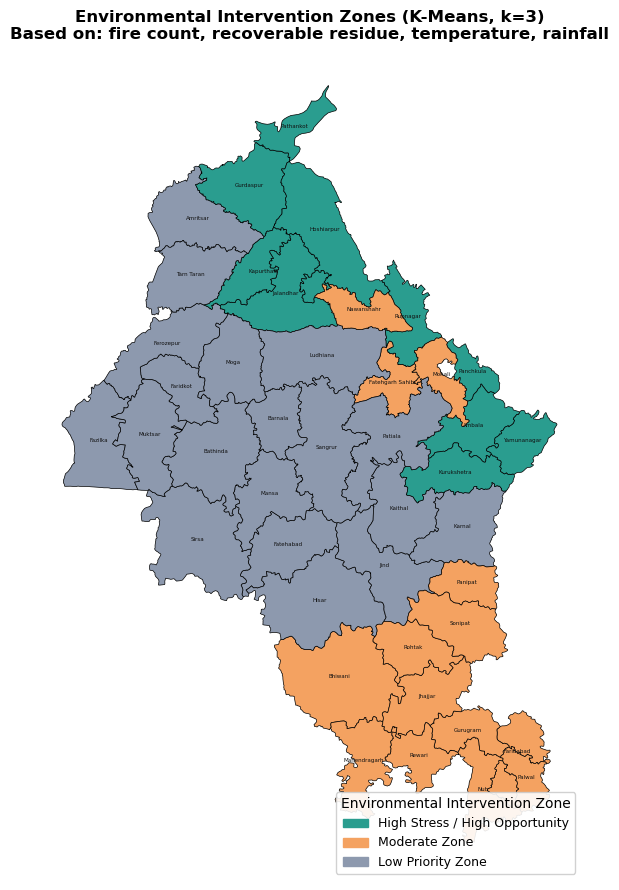

✅ Saved: Outputs/Maps/15_cluster_map.png

Zone distribution:
zone
Low Priority Zone                 19
Moderate Zone                     14
High Stress / High Opportunity    10


In [5]:
# ── Map 2: Environmental Intervention Zones (K-Means, k=3) ────────────────
#
# WHY ENVIRONMENTAL ZONES INSTEAD OF SOCIO CLUSTERS?
# The original Module C plan used socioeconomic data (income, farm size,
# FPO presence, insurance uptake) to identify 'High / Medium / Low
# participation viability' zones — i.e., where FARMERS are ready.
#
# The revised Module C clusters by ENVIRONMENTAL factors:
#   - fire_count and residue → proxy for burning pressure and feedstock
#   - avg_temp and rainfall  → proxy for climate/weather driver of burning
#
# This means the three zones answer a DIFFERENT question:
#   High Stress / High Opportunity  → high burning AND high residue →
#       these districts both need intervention AND have the most feedstock
#       for biogas plants.
#   Moderate Zone → intermediate on both axes → mid-term planning targets.
#   Low Priority Zone → low burning pressure and/or low residue →
#       monitor but do not prioritise for immediate investment.
#
# INTERPRETATION NOTE:
# Unlike the socio-based PVI zones, these environmental zones do NOT
# indicate whether farmers WILL participate — only that the AGRO-CLIMATIC
# conditions make the district a strong/weak candidate for plant siting.
# A separate data collection effort would be needed to recover the
# original PVI intent.

zone_palette = {
    'High Stress / High Opportunity': '#2a9d8f',   # teal
    'Moderate Zone'                 : '#f4a261',   # amber
    'Low Priority Zone'             : '#8d99ae',   # slate
    'Unknown'                       : '#cccccc',   # grey for UTs
}
gdf['color'] = gdf['zone'].map(zone_palette)

fig, ax = plt.subplots(figsize=(10, 9))
gdf.plot(color=gdf['color'], edgecolor='black', linewidth=0.5, ax=ax)

for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['district'], xy=(c.x, c.y), fontsize=4, ha='center', color='#111111')

patches = [
    mpatches.Patch(color=c, label=z)
    for z, c in zone_palette.items() if z != 'Unknown'
]
ax.legend(
    handles=patches,
    title='Environmental Intervention Zone',
    loc='lower right',
    fontsize=9,
    framealpha=0.9
)
ax.set_title(
    'Environmental Intervention Zones (K-Means, k=3)\n'
    'Based on: fire count, recoverable residue, temperature, rainfall',
    fontsize=12, fontweight='bold'
)
ax.axis('off')

plt.tight_layout()
plt.savefig('../Outputs/Maps/15_cluster_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: Outputs/Maps/15_cluster_map.png")

# ── Zone distribution ─────────────────────────────────────────────────────
print("\nZone distribution:")
print(gdf['zone'].value_counts().to_string())

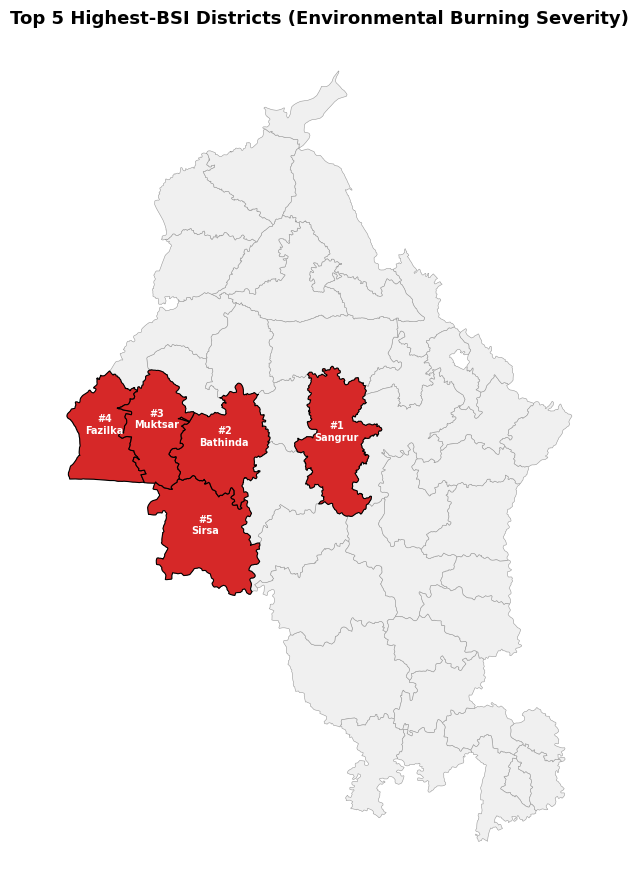


🔥 Top 5 High-BSI Districts:
district   BSI
 Sangrur 100.0
Bathinda  95.1
 Muktsar  90.0
 Fazilka  88.5
   Sirsa  84.4

✅ Saved: Outputs/Maps/15_top5_burning.png


In [6]:
# ── Map 3: Top-5 High-BSI Districts ──────────────────────────────────────
#
# These five districts have the highest composite environmental burning
# severity: they score high on fire count, recoverable residue volume,
# temperature, AND low on suppressing rainfall — all four environmental
# drivers of burning point to maximum urgency here.
#
# Expected top-5 from NB14 outputs:
#   Sangrur (100.0), Bathinda (95.1), Muktsar (90.0), Fazilka (88.5),
#   Sirsa (84.4) — dominated by south-west Punjab and north-west Haryana.

top5 = bsi.nlargest(5, 'BSI')

fig, ax = plt.subplots(figsize=(10, 9))

# Base: all districts in light grey
gdf.plot(color='#f0f0f0', edgecolor='#999999', linewidth=0.4, ax=ax)

# Highlight top-5 in red
top5_gdf = gdf[gdf['district'].isin(top5['district'])]
top5_gdf.plot(color='#d62828', edgecolor='black', linewidth=0.8, ax=ax)

# Label top-5 districts with rank
top5_ranked = top5.reset_index(drop=True)
for _, row in top5_gdf.iterrows():
    c = row.geometry.centroid
    rank_row = top5_ranked[top5_ranked['district'] == row['district']]
    rank     = rank_row.index[0] + 1 if not rank_row.empty else ''
    ax.annotate(
        f"#{rank}\n{row['district']}",
        xy=(c.x, c.y),
        fontsize=7, ha='center', fontweight='bold', color='white'
    )

ax.set_title(
    'Top 5 Highest-BSI Districts (Environmental Burning Severity)',
    fontsize=13, fontweight='bold'
)
ax.axis('off')

plt.tight_layout()
plt.savefig('../Outputs/Maps/15_top5_burning.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n🔥 Top 5 High-BSI Districts:")
print(top5[['district', 'BSI']].to_string(index=False))
print("\n✅ Saved: Outputs/Maps/15_top5_burning.png")

In [7]:
# ── Summary: which zone are top-BSI districts in? ─────────────────────────
# This cross-tabulation verifies that the K-Means zones (NB13) and BSI
# scores (NB14) tell a consistent story.  High-BSI districts should
# predominantly appear in 'High Stress / High Opportunity' zone.
check = gdf[['district', 'BSI', 'zone']].sort_values('BSI', ascending=False).head(15)
print("Top 15 districts by BSI and their K-Means zone:")
print(check.to_string(index=False))

Top 15 districts by BSI and their K-Means zone:
 district   BSI              zone
  Sangrur 100.0 Low Priority Zone
 Bathinda  95.1 Low Priority Zone
  Muktsar  90.0 Low Priority Zone
  Fazilka  88.5 Low Priority Zone
    Sirsa  84.4 Low Priority Zone
Ferozepur  83.0 Low Priority Zone
Fatehabad  80.8 Low Priority Zone
     Moga  80.6 Low Priority Zone
    Mansa  78.0 Low Priority Zone
    Hisar  77.0 Low Priority Zone
 Ludhiana  76.0 Low Priority Zone
 Faridkot  74.3 Low Priority Zone
  Patiala  71.3 Low Priority Zone
     Jind  71.1 Low Priority Zone
  Barnala  70.3 Low Priority Zone
